# Analysis transcription type
### Author: Martin Loza
### Date: 26/01/17s

After analysing the relationship between lncRNA and TF (within 10kb window) we would like to analyse the relationship of different types of transcription: antisense, divergent, etc.

In [20]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "260117"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
ensembl_raw_annotation_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/Analysis_transcription_type/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density
    metrics <- filtered_data %>%
        group_by(ncrna_strand) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [3]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

Let's focus only in lncRNAs related to TF genes 

In [4]:
# Select only observations related to lncRNA and TF genes
data_list_selected <- list()
for (species in names(data_list)) {
    data_list_selected[[species]] <- data_list[[species]] %>%
        filter(gene_biotype == "lncRNA") %>%
        filter(is_TF == TRUE)
}

In [5]:
head(data_list[["human"]], 3)
table(data_list[["human"]]$gene_biotype)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE



              lncRNA                miRNA             misc_RNA 
             4155667                59680                54615 
processed_transcript             ribozyme                 rRNA 
                 199                  289                  788 
     rRNA_pseudogene               scaRNA               snoRNA 
                9135                 1615                24419 
               snRNA                 sRNA 
               43525                  215 

Let's recover the strand annotation of pcg. Let's load the original information to map missing columns

In [6]:
# Load the raw-selected transcripts data
# We have different species, so let's create a list to store the data
data_list_raw = list()

# Search for the available files
files <- list.files(ensembl_raw_annotation_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list_raw[[species_name]] <- read.table(file.path(ensembl_raw_annotation_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list_raw[["human"]], 3)

,row.names,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Strand,Gene.stable.ID,Transcript.stable.ID,Transcript.start..bp.,Transcript.end..bp.,Transcript.type,Gene.type,Gene.name,Gene.description,TSS,is_pcg,is_ncrna
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>
1,1,1,11121,24894,1,ENSG00000290825,ENST00000456328,11850,14416,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11850,FALSE,TRUE
2,2,1,11121,24894,1,ENSG00000290825,ENST00000832823,14404,24894,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],14404,FALSE,TRUE
3,3,1,11121,24894,1,ENSG00000290825,ENST00000832824,11121,14413,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11121,FALSE,TRUE


Let's map the missing columns

In [7]:
colnames(data_list[["human"]])
colnames(data_list_raw[["human"]])

[1] "chromosome"      "ncRNA_id"        "ncrna_tss"       "ncrna_gene_name"
 [5] "ncrna_strand"    "gene_biotype"    "pcg_id"          "pcg_gene_name"  
 [9] "pcg_tss"         "dna_distance"    "strand_distance" "Family"         
[13] "is_TF"

[1] "row.names"                "Chromosome.scaffold.name"
 [3] "Gene.start..bp."          "Gene.end..bp."           
 [5] "Strand"                   "Gene.stable.ID"          
 [7] "Transcript.stable.ID"     "Transcript.start..bp."   
 [9] "Transcript.end..bp."      "Transcript.type"         
[11] "Gene.type"                "Gene.name"               
[13] "Gene.description"         "TSS"                     
[15] "is_pcg"                   "is_ncrna"

In [8]:
# We need to map start, end and strand information from the raw data to the selected data
sel_cols <- c('Transcript.stable.ID','Transcript.start..bp.','Transcript.end..bp.','Strand')
tmp_raw_list <- lapply(data_list_raw, function(df) df[, sel_cols])

# create a new list to store the annotated data
data_ann_list <- list()
for (species in names(data_list)) {
    # Map the lncRNA information
    data_ann_list[[species]] <- data_list[[species]] %>%
        left_join(
            tmp_raw_list[[species]],
            by = c("ncRNA_id" = "Transcript.stable.ID")
        ) %>%
        dplyr::rename(
            lncRNA_start = Transcript.start..bp.,
            lncRNA_end = Transcript.end..bp.,
            lncRNA_strand = Strand
        ) %>% # map the PCG information
        left_join(
            tmp_raw_list[[species]],
            by = c("pcg_id" = "Transcript.stable.ID") 
        ) %>%
        dplyr::rename(
            pcg_start = Transcript.start..bp.,
            pcg_end = Transcript.end..bp.,
            pcg_strand = Strand
        )
}

In [9]:
head(data_ann_list[["human"]] %>% filter(pcg_strand == -1), 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,lncRNA_start,lncRNA_end,lncRNA_strand,pcg_start,pcg_end,pcg_strand
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<int>,<int>,<int>,<int>,<int>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE,54532791,54543732,1,55463001,55464751,-1
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000301200,CDC42EP5,54473296,-59495,-59495,NA,FALSE,54532791,54543732,1,54465026,54473296,-1
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590900,COX6B2,55354540,821749,821749,NA,FALSE,54532791,54543732,1,55350413,55354540,-1


Let's first analyse the sense and antisense pairs

In [10]:
# Let's annotate the transcription direction sense
for (species in names(data_ann_list)) {
    data_ann_list[[species]] <- data_ann_list[[species]] %>%
     mutate(
            transcription_type_1 = case_when(
                lncRNA_strand == pcg_strand ~ "Sense",
                lncRNA_strand != pcg_strand ~ "Antisense",
                TRUE ~ "Unknown"
            )
        ) %>%
        mutate(
            transcription_type_2 = case_when(
                lncRNA_strand == pcg_strand & lncRNA_strand == 1 ~ "Sense-Forward",
                lncRNA_strand == pcg_strand & lncRNA_strand == -1 ~ "Sense-Reverse",
                lncRNA_strand != pcg_strand & pcg_strand == 1 ~ "Antisense-Forward",
                lncRNA_strand != pcg_strand & pcg_strand == -1 ~ "Antisense-Reverse",
                TRUE ~ "Unknown"
            )
        ) 
}

### Density analysis across multiple window sizes

Similar to the width selection analysis, let's analyze how the distribution of Sense vs Antisense pairs changes across different window sizes

In [16]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

# Add absolute distance column if not already present
for (species in names(data_ann_list)) {
    if (!"abs_dna_distance" %in% colnames(data_ann_list[[species]])) {
        data_ann_list[[species]] <- data_ann_list[[species]] %>%
            mutate(abs_dna_distance = abs(dna_distance))
    }
}

In [17]:
# Separate data into Sense and Antisense sets
data_sense_list <- list()
data_antisense_list <- list()

for (species in names(data_ann_list)) {
    data_sense_list[[species]] <- data_ann_list[[species]] %>% 
        filter(transcription_type_1 == "Sense")
    data_antisense_list[[species]] <- data_ann_list[[species]] %>% 
        filter(transcription_type_1 == "Antisense")
}

# Calculate density metrics for Sense pairs
all_density_sense <- list()

for (species in names(data_sense_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        # Count pairs within window
        count_in_window <- data_sense_list[[species]] %>%
            filter(abs_dna_distance <= ws) %>%
            nrow()
        
        # Calculate density
        density <- count_in_window / ws
        
        species_metrics <- rbind(species_metrics, data.frame(
            window_size = ws,
            count = count_in_window,
            density = density
        ))
    }
    
    species_metrics$species <- species
    species_metrics$transcription_type <- "Sense"
    all_density_sense[[species]] <- species_metrics
}

# Calculate density metrics for Antisense pairs
all_density_antisense <- list()

for (species in names(data_antisense_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        # Count pairs within window
        count_in_window <- data_antisense_list[[species]] %>%
            filter(abs_dna_distance <= ws) %>%
            nrow()
        
        # Calculate density
        density <- count_in_window / ws
        
        species_metrics <- rbind(species_metrics, data.frame(
            window_size = ws,
            count = count_in_window,
            density = density
        ))
    }
    
    species_metrics$species <- species
    species_metrics$transcription_type <- "Antisense"
    all_density_antisense[[species]] <- species_metrics
}

# Combine Sense and Antisense metrics
density_sense_df <- do.call(rbind, all_density_sense)
density_antisense_df <- do.call(rbind, all_density_antisense)
density_transcription_df <- rbind(density_sense_df, density_antisense_df)
rownames(density_transcription_df) <- NULL

head(density_transcription_df, 10)

,window_size,count,density,species,transcription_type
,<dbl>,<int>,<dbl>,<chr>,<chr>
1,1e+03,9884,9.884000,human,Sense
2,5e+03,15640,3.128000,human,Sense
3,1e+04,22991,2.299100,human,Sense
4,5e+04,101471,2.029420,human,Sense
5,1e+05,218485,2.184850,human,Sense
6,5e+05,1129239,2.258478,human,Sense
7,1e+06,2111056,2.111056,human,Sense
8,1e+03,841,0.841000,mouse,Sense
9,5e+03,3732,0.746400,mouse,Sense


In [18]:
# Perform statistical testing for Sense vs Antisense at each window size
pvalue_results <- list()

for (sp in unique(density_transcription_df$species)) {
    for (ws in window_sizes) {
        # Get the raw data for this species and window
        sense_data <- data_sense_list[[sp]] %>% 
            filter(abs_dna_distance <= ws)
        antisense_data <- data_antisense_list[[sp]] %>% 
            filter(abs_dna_distance <= ws)
        
        # Get counts
        sense_count <- nrow(sense_data)
        antisense_count <- nrow(antisense_data)
        
        # Calculate densities
        sense_density <- sense_count / ws
        antisense_density <- antisense_count / ws
        
        # Get total counts for each type
        total_sense <- nrow(data_sense_list[[sp]])
        total_antisense <- nrow(data_antisense_list[[sp]])
        
        # Create contingency table: [in_window, not_in_window] x [Sense, Antisense]
        cont_table <- matrix(c(sense_count, total_sense - sense_count,
                               antisense_count, total_antisense - antisense_count),
                             nrow = 2, byrow = FALSE)
        
        test_result <- chisq.test(cont_table)
        
        pvalue_results[[length(pvalue_results) + 1]] <- data.frame(
            species = sp,
            window_size = ws,
            pvalue = test_result$p.value,
            sense_density = sense_density,
            antisense_density = antisense_density,
            sense_count = sense_count,
            antisense_count = antisense_count
        )
    }
}

pvalue_transcription_df <- do.call(rbind, pvalue_results)

# Apply FDR correction (Benjamini-Hochberg)
pvalue_transcription_df <- pvalue_transcription_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

print(pvalue_transcription_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


   species window_size        pvalue sense_density antisense_density
1    human       1e+03  0.000000e+00      9.884000         58.421000
2    human       5e+03  0.000000e+00      3.128000         14.689200
3    human       1e+04  0.000000e+00      2.299100          8.688200
4    human       5e+04  0.000000e+00      2.029420          3.800620
5    human       1e+05  0.000000e+00      2.184850          3.182460
6    human       5e+05 1.215053e-290      2.258478          2.473416
7    human       1e+06           NaN      2.111056          2.239091
8    mouse       1e+03  0.000000e+00      0.841000         26.905000
9    mouse       5e+03  0.000000e+00      0.746400          7.414200
10   mouse       1e+04  0.000000e+00      0.950800          4.589100
11   mouse       5e+04  0.000000e+00      1.403120          2.424220
12   mouse       1e+05  0.000000e+00      1.559230          2.106450
13   mouse       5e+05  0.000000e+00      1.669400          1.807968
14   mouse       1e+06           N

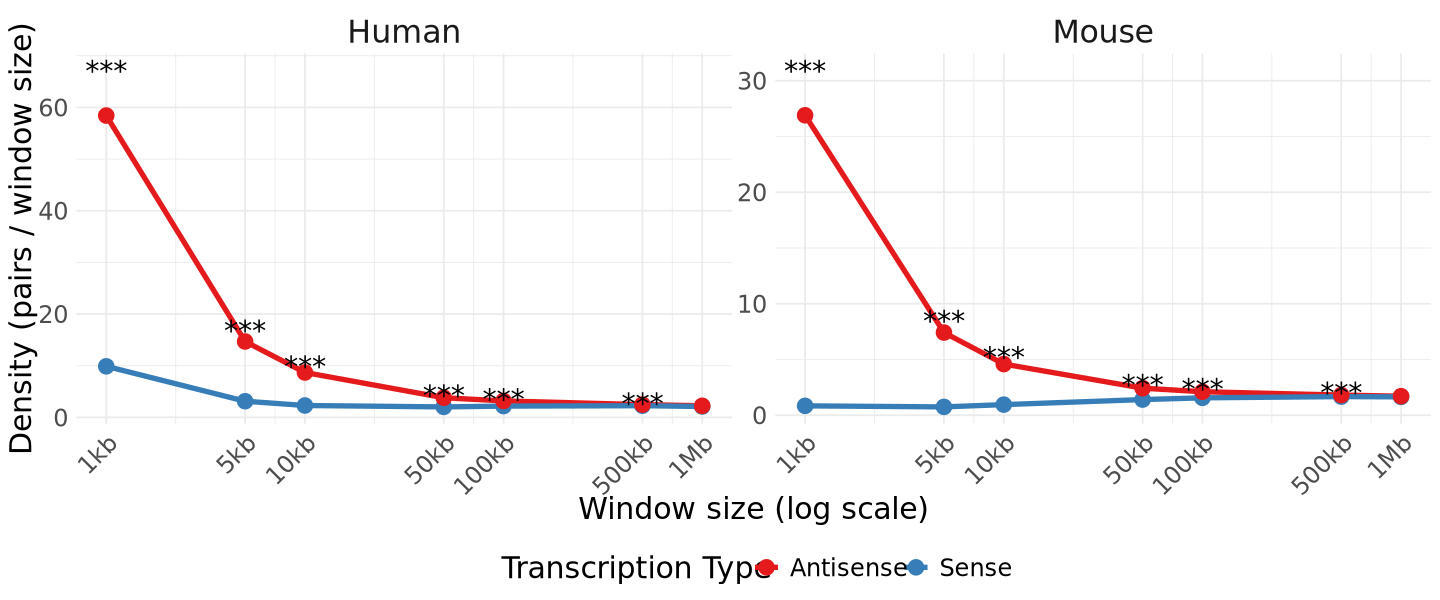

In [19]:
# Visualize Sense vs Antisense density comparison across window sizes
options(repr.plot.width=12, repr.plot.height=5)

# Merge significance information with density data
density_transcription_with_sig <- density_transcription_df %>%
    left_join(pvalue_transcription_df %>% select(species, window_size, significance), 
              by = c("species", "window_size"))

# Calculate y position for significance labels (above the higher point)
density_max_per_window <- density_transcription_with_sig %>%
    group_by(species, window_size) %>%
    summarise(
        max_density = max(density),
        significance = first(significance[significance != ""]),
        .groups = 'drop'
    ) %>%
    filter(!is.na(significance) & significance != "")

p_density_transcription <- density_transcription_df %>%
    ggplot(aes(x = window_size / 1000, y = density, 
               color = transcription_type, group = transcription_type)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    # Add significance labels
    geom_text(data = density_max_per_window,
              aes(x = window_size / 1000, y = max_density * 1.15, label = significance),
              inherit.aes = FALSE, size = 6, color = "black") +
    facet_wrap(~str_to_title(species), scales = "free_y", ncol = 2) +
    scale_color_manual(values = c("Antisense" = red, "Sense" = blue)) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (pairs / window size)",
         color = "Transcription Type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_transcription

In [ ]:
# # Save the main figure
# ggsave(filename = file.path(out_dir, paste0("Density_antisense_vs_sense_", date, ".pdf")),
#     plot = p_density_transcription, 
#     width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

Now, let's investigate other types of transcription

In [40]:
# Hierarchical analysis: Compare Forward vs Reverse within each transcription type
# Include both human and mouse data

# Separate data by all four transcription_type_2 categories for both species
data_type2_list <- list()

for (species in c("human", "mouse")) {
    for (type in c("Sense-Forward", "Sense-Reverse", "Antisense-Forward", "Antisense-Reverse")) {
        key <- paste(species, type, sep = "_")
        data_type2_list[[key]] <- data_ann_list[[species]] %>% 
            filter(transcription_type_2 == type)
    }
}

# Calculate density metrics for all 4 types x 2 species
all_density_type2 <- list()

for (key in names(data_type2_list)) {
    type_metrics <- data.frame()
    
    # Extract species and type from key
    parts <- strsplit(key, "_")[[1]]
    species <- parts[1]
    type <- paste(parts[-1], collapse = "-")
    
    for (ws in window_sizes) {
        # Count pairs within window
        count_in_window <- data_type2_list[[key]] %>%
            filter(abs_dna_distance <= ws) %>%
            nrow()
        
        # Calculate density
        density <- count_in_window / ws
        
        type_metrics <- rbind(type_metrics, data.frame(
            window_size = ws,
            count = count_in_window,
            density = density,
            species = species,
            transcription_type_2 = type
        ))
    }
    
    all_density_type2[[key]] <- type_metrics
}

# Combine all metrics
density_type2_df <- do.call(rbind, all_density_type2)
rownames(density_type2_df) <- NULL

# Add grouping variables for easier plotting
density_type2_df <- density_type2_df %>%
    mutate(
        sense_group = ifelse(grepl("Sense", transcription_type_2), "Sense", "Antisense"),
        strand = ifelse(grepl("Forward", transcription_type_2), "Forward", "Reverse")
    )

head(density_type2_df, 10)

,window_size,count,density,species,transcription_type_2,sense_group,strand
,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,1e+03,2807,2.807000,human,Sense-Forward,Sense,Forward
2,5e+03,6401,1.280200,human,Sense-Forward,Sense,Forward
3,1e+04,10281,1.028100,human,Sense-Forward,Sense,Forward
4,5e+04,48874,0.977480,human,Sense-Forward,Sense,Forward
5,1e+05,109059,1.090590,human,Sense-Forward,Sense,Forward
6,5e+05,568975,1.137950,human,Sense-Forward,Sense,Forward
7,1e+06,1076648,1.076648,human,Sense-Forward,Sense,Forward
8,1e+03,7077,7.077000,human,Sense-Reverse,Sense,Reverse
9,5e+03,9239,1.847800,human,Sense-Reverse,Sense,Reverse


In [41]:
# Statistical testing: Forward vs Reverse within Sense pairs (both species)
pvalue_sense_strand <- list()

for (species in c("human", "mouse")) {
    for (ws in window_sizes) {
        # Get data for Sense-Forward and Sense-Reverse
        forward_key <- paste(species, "Sense-Forward", sep = "_")
        reverse_key <- paste(species, "Sense-Reverse", sep = "_")
        
        forward_data <- data_type2_list[[forward_key]] %>% 
            filter(abs_dna_distance <= ws)
        reverse_data <- data_type2_list[[reverse_key]] %>% 
            filter(abs_dna_distance <= ws)
        
        # Get counts
        forward_count <- nrow(forward_data)
        reverse_count <- nrow(reverse_data)
        
        # Get total counts
        total_forward <- nrow(data_type2_list[[forward_key]])
        total_reverse <- nrow(data_type2_list[[reverse_key]])
        
        # Create contingency table
        cont_table <- matrix(c(forward_count, total_forward - forward_count,
                               reverse_count, total_reverse - reverse_count),
                             nrow = 2, byrow = FALSE)
        
        test_result <- chisq.test(cont_table)
        
        pvalue_sense_strand[[length(pvalue_sense_strand) + 1]] <- data.frame(
            species = species,
            window_size = ws,
            pvalue = test_result$p.value,
            forward_count = forward_count,
            reverse_count = reverse_count,
            forward_density = forward_count / ws,
            reverse_density = reverse_count / ws
        )
    }
}

pvalue_sense_strand_df <- do.call(rbind, pvalue_sense_strand)

# Apply FDR correction
pvalue_sense_strand_df <- pvalue_sense_strand_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

print("Sense pairs: Forward vs Reverse")
print(pvalue_sense_strand_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


[1] "Sense pairs: Forward vs Reverse"
   species window_size        pvalue forward_count reverse_count
1    human       1e+03  0.000000e+00          2807          7077
2    human       5e+03 4.517460e-141          6401          9239
3    human       1e+04  8.757014e-82         10281         12710
4    human       5e+04  1.648666e-76         48874         52597
5    human       1e+05  9.448452e-27        109059        109426
6    human       5e+05  7.902048e-82        568975        560264
7    human       1e+06           NaN       1076648       1034408
8    mouse       1e+03  1.746108e-01           413           428
9    mouse       5e+03  1.978031e-01          1962          1770
10   mouse       1e+04  2.893517e-03          4752          4756
11   mouse       5e+04  1.436491e-13         37093         33063
12   mouse       1e+05  2.759705e-28         82382         73541
13   mouse       5e+05  6.868884e-05        428649        406051
14   mouse       1e+06           NaN        847550  

In [42]:
# Statistical testing: Forward vs Reverse within Antisense pairs (both species)
pvalue_antisense_strand <- list()

for (species in c("human", "mouse")) {
    for (ws in window_sizes) {
        # Get data for Antisense-Forward and Antisense-Reverse
        forward_key <- paste(species, "Antisense-Forward", sep = "_")
        reverse_key <- paste(species, "Antisense-Reverse", sep = "_")
        
        forward_data <- data_type2_list[[forward_key]] %>% 
            filter(abs_dna_distance <= ws)
        reverse_data <- data_type2_list[[reverse_key]] %>% 
            filter(abs_dna_distance <= ws)
        
        # Get counts
        forward_count <- nrow(forward_data)
        reverse_count <- nrow(reverse_data)
        
        # Get total counts
        total_forward <- nrow(data_type2_list[[forward_key]])
        total_reverse <- nrow(data_type2_list[[reverse_key]])
        
        # Create contingency table
        cont_table <- matrix(c(forward_count, total_forward - forward_count,
                               reverse_count, total_reverse - reverse_count),
                             nrow = 2, byrow = FALSE)
        
        test_result <- chisq.test(cont_table)
        
        pvalue_antisense_strand[[length(pvalue_antisense_strand) + 1]] <- data.frame(
            species = species,
            window_size = ws,
            pvalue = test_result$p.value,
            forward_count = forward_count,
            reverse_count = reverse_count,
            forward_density = forward_count / ws,
            reverse_density = reverse_count / ws
        )
    }
}

pvalue_antisense_strand_df <- do.call(rbind, pvalue_antisense_strand)

# Apply FDR correction
pvalue_antisense_strand_df <- pvalue_antisense_strand_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

print("Antisense pairs: Forward vs Reverse")
print(pvalue_antisense_strand_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


[1] "Antisense pairs: Forward vs Reverse"
   species window_size        pvalue forward_count reverse_count
1    human       1e+03 1.334595e-312         26211         32210
2    human       5e+03 1.251993e-198         34610         38836
3    human       1e+04 7.900116e-229         41015         45867
4    human       5e+04 2.178391e-254         92809         97222
5    human       1e+05  4.835226e-44        163677        154569
6    human       5e+05  3.722957e-02        650940        585768
7    human       1e+06           NaN       1177141       1061950
8    mouse       1e+03  1.465092e-02         12826         14079
9    mouse       5e+03  6.754498e-02         17772         19299
10   mouse       1e+04  2.050670e-01         22082         23809
11   mouse       5e+04  1.513827e-03         59212         61999
12   mouse       1e+05  9.727193e-08        103121        107524
13   mouse       5e+05  4.348167e-02        436970        467014
14   mouse       1e+06           NaN        8263

In [43]:
# Create individual plots for all 4 combinations (2 species x 2 transcription types)

# Color palettes with alpha variation
blue_solid <- blue
blue_light <- adjustcolor(blue, alpha.f = 0.6)
red_solid <- red
red_light <- adjustcolor(red, alpha.f = 0.6)

# Function to create plot for a given species and sense group
create_strand_plot <- function(species_name, sense_group_name, color_solid, color_light) {
    # Filter data
    plot_data <- density_type2_df %>%
        filter(species == species_name, sense_group == sense_group_name)
    
    # Get appropriate pvalue dataframe
    if (sense_group_name == "Sense") {
        pvalue_data <- pvalue_sense_strand_df
    } else {
        pvalue_data <- pvalue_antisense_strand_df
    }
    
    # Prepare significance data
    sig_data <- plot_data %>%
        group_by(window_size) %>%
        summarise(
            max_density = max(density),
            .groups = 'drop'
        ) %>%
        left_join(pvalue_data %>% 
                  filter(species == species_name) %>%
                  select(window_size, significance), 
                  by = "window_size") %>%
        filter(!is.na(significance) & significance != "")
    
    # Create plot
    p <- plot_data %>%
        ggplot(aes(x = window_size / 1000, y = density, 
                   color = strand, linetype = strand, group = strand)) +
        geom_line(linewidth = line_size) +
        geom_point(size = dot_size) +
        # Add significance labels
        geom_text(data = sig_data,
                  aes(x = window_size / 1000, y = max_density * 1.15, label = significance),
                  inherit.aes = FALSE, size = 6, color = "black") +
        scale_color_manual(values = c("Forward" = color_solid, "Reverse" = color_light),
                           labels = c("Forward", "Reverse")) +
        scale_linetype_manual(values = c("Forward" = "solid", "Reverse" = "dashed")) +
        scale_x_log10(breaks = window_sizes / 1000, 
                      labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
        theme_minimal() +
        labs(title = paste(str_to_title(species_name), "-", sense_group_name, "Pairs"),
             x = "Window size (log scale)",
             y = "Density (pairs / window size)",
             color = "Strand",
             linetype = "Strand") +
        theme(text = element_text(size = text_size),
              plot.title = element_text(size = text_size),
              axis.text.x = element_text(angle = 45, hjust = 1),
              legend.position = "bottom")
    
    return(p)
}

# Create all 4 plots
p_human_sense <- create_strand_plot("human", "Sense", blue_solid, blue_light)
p_human_antisense <- create_strand_plot("human", "Antisense", red_solid, red_light)
p_mouse_sense <- create_strand_plot("mouse", "Sense", blue_solid, blue_light)
p_mouse_antisense <- create_strand_plot("mouse", "Antisense", red_solid, red_light)

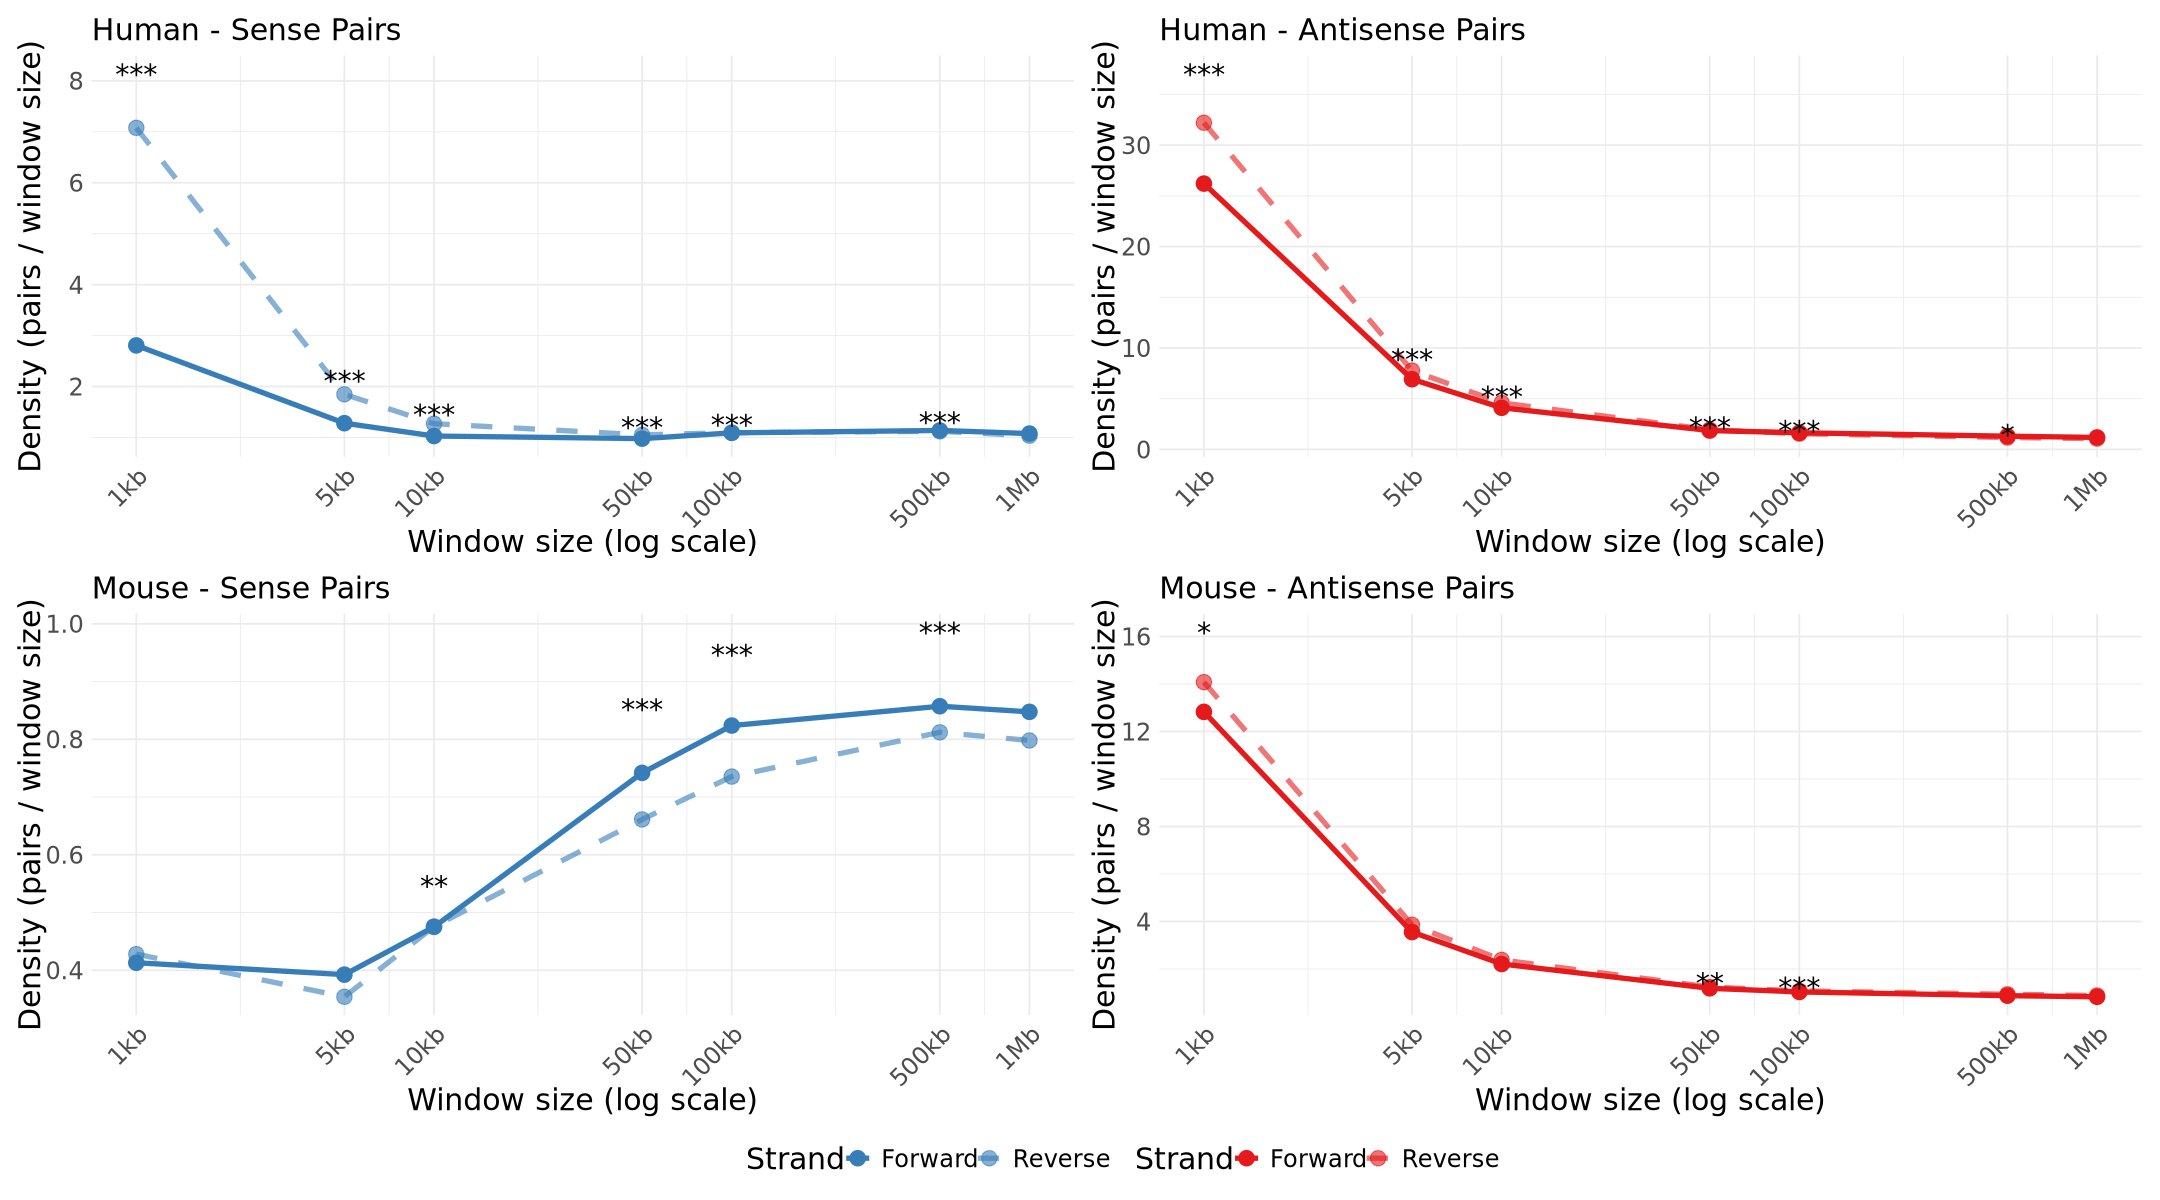

In [44]:
# Combine all 4 plots in a 2x2 grid: Human (top), Mouse (bottom)
options(repr.plot.width=18, repr.plot.height=10)

p_combined_all <- (p_human_sense | p_human_antisense) / 
                  (p_mouse_sense | p_mouse_antisense) +
    plot_layout(guides = 'collect') & 
    theme(legend.position = 'bottom')

p_combined_all

In [47]:

ggsave(filename = file.path(out_dir, paste0("Supplementary_Figure_density_strand_comparison_", date, ".pdf")),
    plot = p_combined_all, 
    width = width, height = 10.0, units = "in", dpi = dpi)